In [1]:
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# SAC KL vs. Gaussian KL

In [2]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/"

# Get all available output folders
out_folders = ['SAC_KL', 'GaussianKL']

In [3]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)
    
    # Find all weight log files (e.g., `dataset_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "mosi_weights_log_epoch*.csv"))
    
    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch
        df = pd.read_csv(log_file)
        df['epoch'] = epoch_num
        df['out_folder'] = out_folder  # Store experiment name
        
        # **Assign KL_Type based on modality**
        df_long = df.melt(id_vars=['epoch', 'out_folder', 'ids'], 
                          value_vars=['kl_text', 'kl_audio', 'kl_video'], 
                          var_name="KL_Type", 
                          value_name="KL_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Show summary statistics per epoch and modality
summary_stats = df_weights.groupby(['epoch', 'out_folder', 'KL_Type'])['KL_Value'].describe()


In [4]:
df_weights.head()

,epoch,out_folder,ids,KL_Type,KL_Value
0,1,SAC_KL,c7UH_rxdZv4_10,kl_text,0.072258
1,1,SAC_KL,c7UH_rxdZv4_9,kl_text,0.030568
2,1,SAC_KL,c7UH_rxdZv4_6,kl_text,0.019479
3,1,SAC_KL,c7UH_rxdZv4_27,kl_text,0.047868
4,1,SAC_KL,c7UH_rxdZv4_20,kl_text,0.010091


In [5]:
summary_stats


count      mean       std  min       25%       50%  \
epoch out_folder KL_Type                                                        
1     GaussianKL kl_audio  686.0  0.201265  0.150549  0.0  0.085852  0.180498   
                 kl_text   686.0  0.077128  0.123832  0.0  0.008648  0.032089   
                 kl_video  686.0  0.249510  0.187243  0.0  0.102399  0.222180   
      SAC_KL     kl_audio  686.0  0.191319  0.143998  0.0  0.081270  0.167658   
                 kl_text   686.0  0.083138  0.117635  0.0  0.019272  0.040254   
                 kl_video  686.0  0.250552  0.186181  0.0  0.100894  0.219428   
2     GaussianKL kl_audio  686.0  0.294275  0.188649  0.0  0.146402  0.291248   
                 kl_text   686.0  0.048902  0.092110  0.0  0.003283  0.017453   
                 kl_video  686.0  0.314587  0.201834  0.0  0.147090  0.310948   
      SAC_KL     kl_audio  686.0  0.216483  0.162650  0.0  0.090750  0.191813   
                 kl_text   686.0  0.065788  0.103654  0.0  0.015172  0.032260   
                 kl_video  686.0  0.245475  0.186003  0.0  0.097799  0.212655   
3     GaussianKL kl_audio  686.0  0.254178  0.207345  0.0  0.071071  0.220662   
                 kl_text   686.0  0.058884  0.105412  0.0  0.003804  0.019636   
                 kl_video  686.0  0.277843  0.224379  0.0  0.076619  0.247620   
      SAC_KL     kl_audio  686.0  0.228724  0.214197  0.0  0.045516  0.162288   
                 kl_text   686.0  0.035437  0.066666  0.0  0.009039  0.016532   
                 kl_video  686.0  0.232984  0.211236  0.0  0.053188  0.170020   
4     GaussianKL kl_audio  686.0  0.235583  0.202918  0.0  0.044676  0.200180   
                 kl_text   686.0  0.045827  0.088979  0.0  0.003623  0.015708   
                 kl_video  686.0  0.280239  0.237257  0.0  0.056233  0.249584   
      SAC_KL     kl_audio  686.0  0.233133  0.184618  0.0  0.058464  0.212092   
                 kl_text   686.0  0.061576  0.112564  0.0  0.011808  0.023888   
                 kl_video  686.0  0.291427  0.229751  0.0  0.085707  0.261199   
6     SAC_KL     kl_audio  686.0  0.190061  0.179300  0.0  0.036422  0.136180   
                 kl_text   686.0  0.048070  0.070099  0.0  0.020509  0.028912   
                 kl_video  686.0  0.205508  0.189510  0.0  0.039720  0.163043   
7     GaussianKL kl_audio  686.0  0.183396  0.160767  0.0  0.041787  0.154554   
                 kl_text   686.0  0.036742  0.074687  0.0  0.002425  0.012231   
                 kl_video  686.0  0.230526  0.200938  0.0  0.054244  0.187469   
      SAC_KL     kl_audio  686.0  0.142724  0.158001  0.0  0.019946  0.089274   
                 kl_text   686.0  0.085136  0.101344  0.0  0.036867  0.053445   
                 kl_video  686.0  0.183623  0.197120  0.0  0.033572  0.115702   
8     GaussianKL kl_audio  686.0  0.198406  0.183225  0.0  0.045148  0.147532   
                 kl_text   686.0  0.040914  0.080597  0.0  0.003552  0.014981   
                 kl_video  686.0  0.217072  0.196561  0.0  0.060606  0.161558   
9     SAC_KL     kl_audio  686.0  0.173260  0.175535  0.0  0.036569  0.114008   
                 kl_text   686.0  0.067616  0.090072  0.0  0.029166  0.041419   
                 kl_video  686.0  0.199081  0.199664  0.0  0.044220  0.120220   
10    GaussianKL kl_audio  686.0  0.204485  0.178559  0.0  0.041460  0.172052   
                 kl_text   686.0  0.042104  0.085560  0.0  0.003293  0.014723   
                 kl_video  686.0  0.231587  0.207181  0.0  0.044057  0.194443   

                                75%  max  
epoch out_folder KL_Type                  
1     GaussianKL kl_audio  0.286834  1.0  
                 kl_text   0.090317  1.0  
                 kl_video  0.351869  1.0  
      SAC_KL     kl_audio  0.271691  1.0  
                 kl_text   0.096583  1.0  
                 kl_video  0.349946  1.0  
2     GaussianKL kl_audio  0.424354  1.0  
                 kl_text   0.058013  1.0  
                 kl_video  0.447

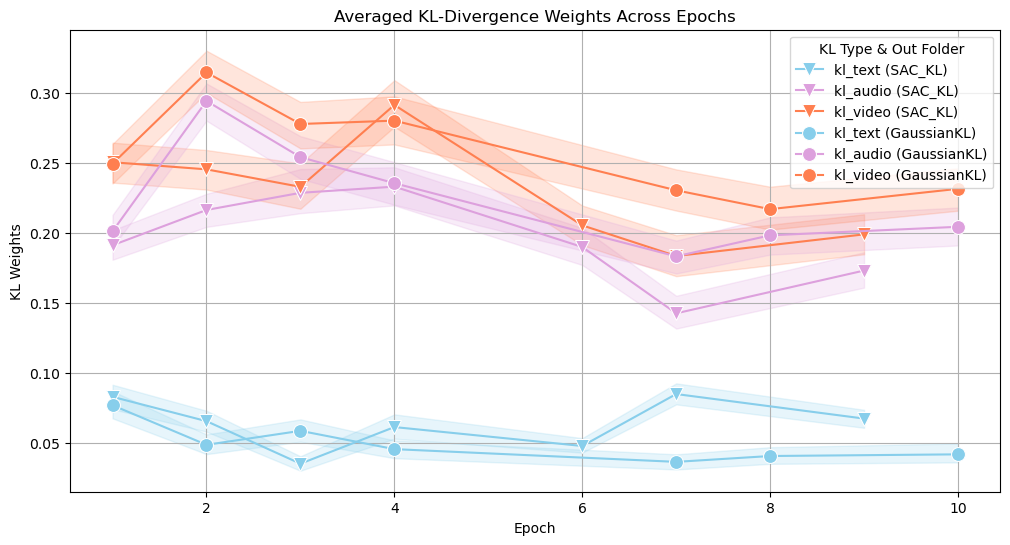

In [6]:
# **Plot KL Weight Evolution with Correct Markers and Colors**
plt.figure(figsize=(12, 6))

# Set marker types for different out_folders (GaussianKL vs SAC_KL)
marker_map = {'GaussianKL': 'o', 'SAC_KL': 'v'}
modality_colors = {'kl_text': 'skyblue', 'kl_audio': 'plum', 'kl_video': 'coral'}

# Iterate through out_folders (experiments) and KL Types
for out_folder in df_weights["out_folder"].unique():
    for modality, color in modality_colors.items():
        sns.lineplot(
            data=df_weights[(df_weights["out_folder"] == out_folder) & (df_weights["KL_Type"] == modality)], 
            x="epoch", 
            y="KL_Value", 
            marker=marker_map.get(out_folder), 
            markersize=10,
            linestyle="-", 
            color=color,
            label=f"{modality} ({out_folder})"
        )

plt.title("Averaged KL-Divergence Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL Weights")
plt.legend(title="KL Type & Out Folder")
plt.grid()
plt.show()

# SAC KL vs. KL + CC

In [7]:
# Base path where all output folders are stored
base_path = "/data/wang/junh/results/MMIM/"

# Get all available output folders
out_folders = ['SAC_KL', 'kl_cc']

In [8]:
# Initialize dataframe to store weight logs
all_weights = []

for out_folder in out_folders:
    folder_path = os.path.join(base_path, out_folder)

    # Find all weight log files (e.g., `*_weights_log_epochX.csv`)
    weight_logs = glob.glob(os.path.join(folder_path, "*_weights_log_epoch*.csv"))

    for log_file in weight_logs:
        epoch_num = int(log_file.split("_epoch")[-1].split(".csv")[0])  # Extract epoch number
        df = pd.read_csv(log_file)
        df["epoch"] = epoch_num
        df["out_folder"] = out_folder  # Store experiment name
        
        # Convert KL weights and Final Weights into long format
        if out_folder == "SAC_KL":
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["kl_text", "kl_audio", "kl_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")
        else:  # kl_cc contains final weights
            df_long = df.melt(id_vars=["epoch", "out_folder", "ids"], 
                              value_vars=["final_weight_text", "final_weight_audio", "final_weight_video"], 
                              var_name="Weight_Type", value_name="Weight_Value")

        all_weights.append(df_long)

# Concatenate all weight logs
df_weights = pd.concat(all_weights, ignore_index=True)

# Map weight names for better understanding
weight_name_map = {
    "kl_text": "KL Text", "kl_audio": "KL Audio", "kl_video": "KL Video",
    "final_weight_text": "Final Weight Text", "final_weight_audio": "Final Weight Audio",
    "final_weight_video": "Final Weight video"
}
df_weights["Weight_Type"] = df_weights["Weight_Type"].map(weight_name_map)

In [9]:
# Compute summary statistics per epoch & modality
df_weights.groupby(["epoch", "out_folder", "Weight_Type"])["Weight_Value"].describe()


count      mean       std  min  \
epoch out_folder Weight_Type                                           
1     SAC_KL     KL Audio            5345.0  0.094300  0.164451  0.0   
                 KL Text             5345.0  0.031960  0.067988  0.0   
                 KL Video            5345.0  0.091324  0.158683  0.0   
      kl_cc      Final Weight Audio  5345.0  0.019720  0.039184  0.0   
                 Final Weight Text   5345.0  0.025280  0.053693  0.0   
                 Final Weight video  5345.0  0.012269  0.027445  0.0   
2     SAC_KL     KL Audio            5345.0  0.143543  0.194817  0.0   
                 KL Text             5345.0  0.022936  0.057405  0.0   
                 KL Video            5345.0  0.130039  0.175266  0.0   
      kl_cc      Final Weight Audio  5345.0  0.026923  0.044798  0.0   
                 Final Weight Text   5345.0  0.017804  0.043219  0.0   
                 Final Weight video  5345.0  0.017945  0.033436  0.0   
3     SAC_KL     KL Audio             686.0  0.228724  0.214197  0.0   
                 KL Text              686.0  0.035437  0.066666  0.0   
                 KL Video             686.0  0.232984  0.211236  0.0   
      kl_cc      Final Weight Audio   686.0  0.010537  0.008151  0.0   
                 Final Weight Text    686.0  0.037633  0.085599  0.0   
                 Final Weight video   686.0  0.005483  0.004190  0.0   
4     SAC_KL     KL Audio             686.0  0.233133  0.184618  0.0   
                 KL Text              686.0  0.061576  0.112564  0.0   
                 KL Video             686.0  0.291427  0.229751  0.0   
      kl_cc      Final Weight Audio   686.0  0.007649  0.006702  0.0   
                 Final Weight Text    686.0  0.061948  0.088555  0.0   
                 Final Weight video   686.0  0.005569  0.004904  0.0   
5     kl_cc      Final Weight Audio   686.0  0.011503  0.010937  0.0   
                 Final Weight Text    686.0  0.027658  0.062180  0.0   
                 Final Weight video   686.0  0.000002  0.000002  0.0   
6     SAC_KL     KL Audio             686.0  0.190061  0.179300  0.0   
                 KL Text              686.0  0.048070  0.070099  0.0   
                 KL Video             686.0  0.205508  0.189510  0.0   
7     SAC_KL     KL Audio             686.0  0.142724  0.158001  0.0   
                 KL Text              686.0  0.085136  0.101344  0.0   
                 KL Video             686.0  0.183623  0.197120  0.0   
8     kl_cc      Final Weight Audio   686.0  0.009427  0.009106  0.0   
                 Final Weight Text    686.0  0.031254  0.067304  0.0   
                 Final Weight video   686.0  0.005022  0.004922  0.0   
9     SAC_KL     KL Audio             686.0  0.173260  0.175535  0.0   
                 KL Text              686.0  0.067616  0.090072  0.0   
                 KL Video             686.0  0.199081  0.199664  0.0   
10    kl_cc      Final Weight Audio   686.0  0.007261  0.005761  0.0   
                 Final Weight Text    686.0  0.039141  0.076047  0.0   
                 Final Weight video   686.0  0.002322  0.001826  0.0   
12    kl_cc      Final Weight Audio   686.0  0.005166  0.004179  0.0   
                 Final Weight Text    686.0  0.036229  0.075053  0.0   
                 Final Weight video   686.0  0.004576  0.003732  0.0   
14    kl_cc      Final Weight Audio   686.0  0.005721  0.004827  0.0   
                 Final Weight Text    686.0  0.045779  0.093139  0.0   
                 Final Weight video   686.0  0.004103  0.003524  0.0   

                                              25%       50%       75%  \
epoch out_folder Weight_Type                                            
1     SAC_KL     KL Audio            5.418601e-03  0.022998  0.092411   
                 KL Text             3.645447e-03  0.010812  0.029272   
                 KL Video            5.760550e-03  0.023130  0.082741   
      kl_cc      Final Weight Audio  1.332709e-03  0.005283  0.016651   

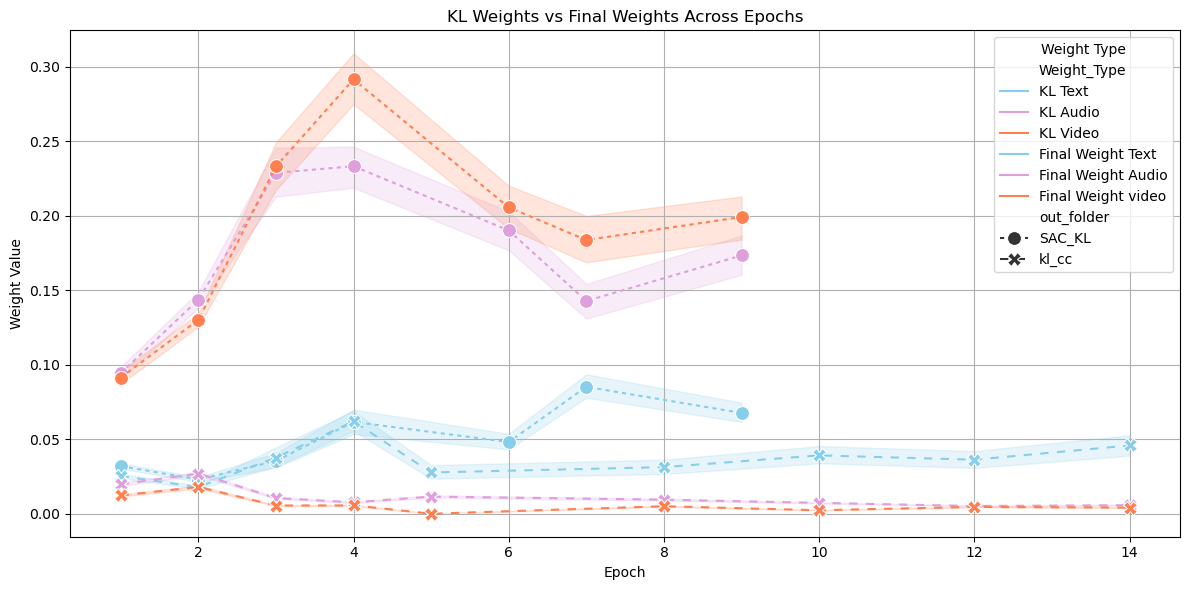

In [11]:
plt.figure(figsize=(12, 6))

# Set line styles for different weight types\
palette = {"KL Text": "skyblue", "KL Audio": "plum", "KL Video": "coral",
           "Final Weight Text": "skyblue", "Final Weight Audio": "plum", "Final Weight video": "coral"}

# Define line styles as tuples for Seaborn
line_styles = {"SAC_KL": (2, 2), "kl_cc": (4, 4)}  # (dash_length, gap_length)

# Plot KL weights from SAC_KL and final weights from kl_cc
sns.lineplot(
    data=df_weights, x="epoch", y="Weight_Value", hue="Weight_Type", style="out_folder", markersize=10,
    markers=True, dashes=[line_styles[k] for k in df_weights["out_folder"].unique()], palette=palette
)

plt.title("KL Weights vs Final Weights Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(title="Weight Type")
plt.grid()

# Save and Show
plt.tight_layout()
plt.show()


# KL + CC vs. KL + MI